In [1]:
# 导入必要的库：pandas用于数据处理，seaborn和matplotlib用于可视化
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [41]:
# 设置中文字体，避免图表中文乱码，并处理负号显示问题
plt.rcParams['font.family'] = 'SimHei'  # 替换为中文字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号'-'显示为方块的问题

### 1.检查数据：形状、类型、缺失值

In [38]:
# 读取泰坦尼克号训练数据集
df = pd.read_csv("train.csv")
# 查看数据集的列名
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [39]:
# 查看数值型列的统计描述（均值、标准差、四分位数等），初步了解数据分布
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# 查看数据集整体信息：行数、列数、各列数据类型和非空值数量
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
# 统计每列的缺失值数量，找出数据中缺失较多的列
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
# 将缺失值数量按降序排列，方便快速定位缺失最严重的列
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

In [8]:
# 计算每列缺失值所占百分比，更直观地评估缺失程度
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent.sort_values(ascending=False)

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64

In [9]:
# Cabin（客舱号）缺失率高达77%，填充为"Unknown"表示未知
df["Cabin"] = df["Cabin"].fillna("Unknown")

In [10]:
# Age（年龄）缺失约20%，使用中位数填充，中位数对异常值更稳健
df['Age'] = df['Age'].fillna(df['Age'].median())

In [11]:
# Embarked（登船港口）仅缺失2个值，填充为"Unknown"表示未知
df["Embarked"] = df["Embarked"].fillna("Unknown")

### 2.按性别、阶级和年龄组分析生存率

In [12]:
# 将年龄按区间分组，便于分析不同年龄段对生存率的影响
bins = [0, 12, 18, 30, 50, 100]
labels = ['Child (0-12)', 'Teen (13-18)', 'Young Adult (19-30)', 'Middle Age (31-50)', 'Senior (51+)']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

In [13]:
# 按性别分组，计算平均生存率
survival_by_sex = df.groupby('Sex')['Survived'].mean().reset_index()
print(survival_by_sex)

      Sex  Survived
0  female  0.742038
1    male  0.188908


In [14]:
# 按年龄段分组，计算平均生存率
survival_by_age = df.groupby('AgeGroup')['Survived'].mean().reset_index()
print(survival_by_age)

              AgeGroup  Survived
0         Child (0-12)  0.573529
1         Teen (13-18)  0.488889
2  Young Adult (19-30)  0.328125
3   Middle Age (31-50)  0.417969
4         Senior (51+)  0.364865


In [15]:
# 按舱位等级分组，计算平均生存率
survival_by_pclass = df.groupby('Pclass')['Survived'].mean().reset_index()
print(survival_by_pclass)

   Pclass  Survived
0       1  0.629630
1       2  0.472826
2       3  0.242363


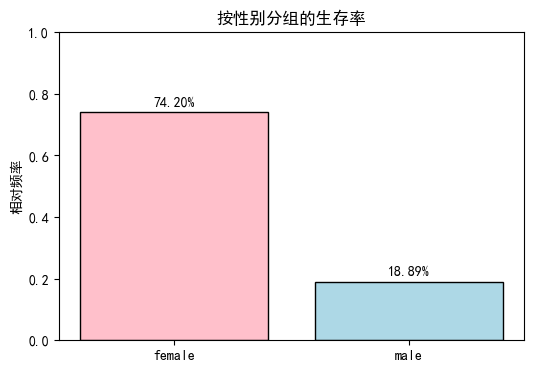

In [52]:
# 绘制性别生存率的柱状图
plt.figure(figsize=(6, 4))
plt.bar(survival_by_sex['Sex'], survival_by_sex['Survived'],
        color=['pink', 'lightblue'], edgecolor='black')
plt.title('按性别分组的生存率')
plt.ylabel('相对频率')
plt.ylim(0, 1)
# 在每个柱子上方添加数值标签，以百分比形式显示
for i, v in enumerate(survival_by_sex['Survived']):
    plt.text(i, v + 0.02, f'{v:.2%}', ha='center')
plt.show()

### 由上图可见女性生存率远高于男性

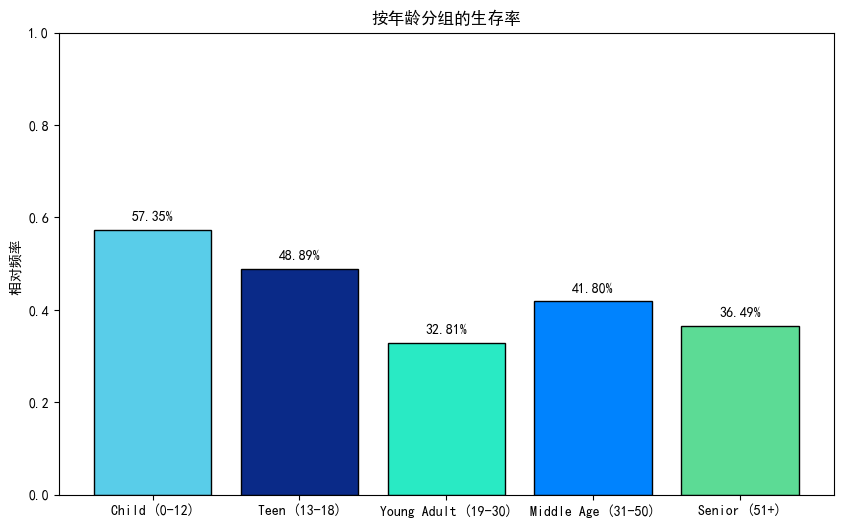

In [51]:
# 绘制各年龄段生存率的柱状图
plt.figure(figsize=(10,6))
plt.bar(survival_by_age['AgeGroup'], survival_by_age['Survived'],
        color=['#59cde9', '#0a2a88','#29eac4','#0083fe','#5cdb95'], edgecolor='black')
plt.title('按年龄分组的生存率')
plt.ylabel('相对频率 ')
plt.ylim(0, 1)
# 在每个柱子上方添加数值标签，以百分比形式显示
for i, v in enumerate(survival_by_age['Survived']):
    plt.text(i, v + 0.02, f'{v:.2%}', ha='center')
plt.show()

### 由上图可见儿童生存率最高，年轻人最低。

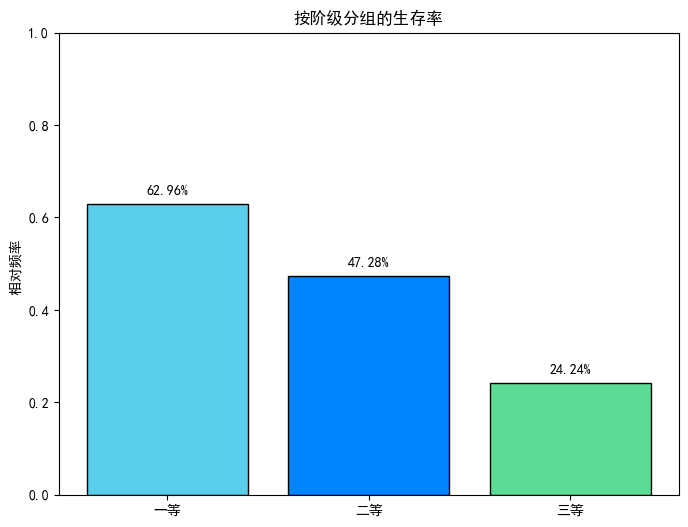

In [53]:
# 绘制舱位等级生存率的柱状图，将x轴标签替换为中文
xtick_labels = ['一等', '二等', '三等'] 
plt.figure(figsize=(8,6))
plt.bar(xtick_labels, survival_by_pclass['Survived'],
        color=['#59cde9','#0083fe','#5cdb95'], edgecolor='black')
plt.title('按阶级分组的生存率')
plt.ylabel('相对频率 ')
plt.ylim(0, 1)
# 在每个柱子上方添加数值标签，以百分比形式显示
for i, v in enumerate(survival_by_pclass['Survived']):
    plt.text(i, v + 0.02, f'{v:.2%}', ha='center')
plt.show()

### 由上图可知头等舱生存率最高，三等舱最低。

### 3.各特征相关性热力图

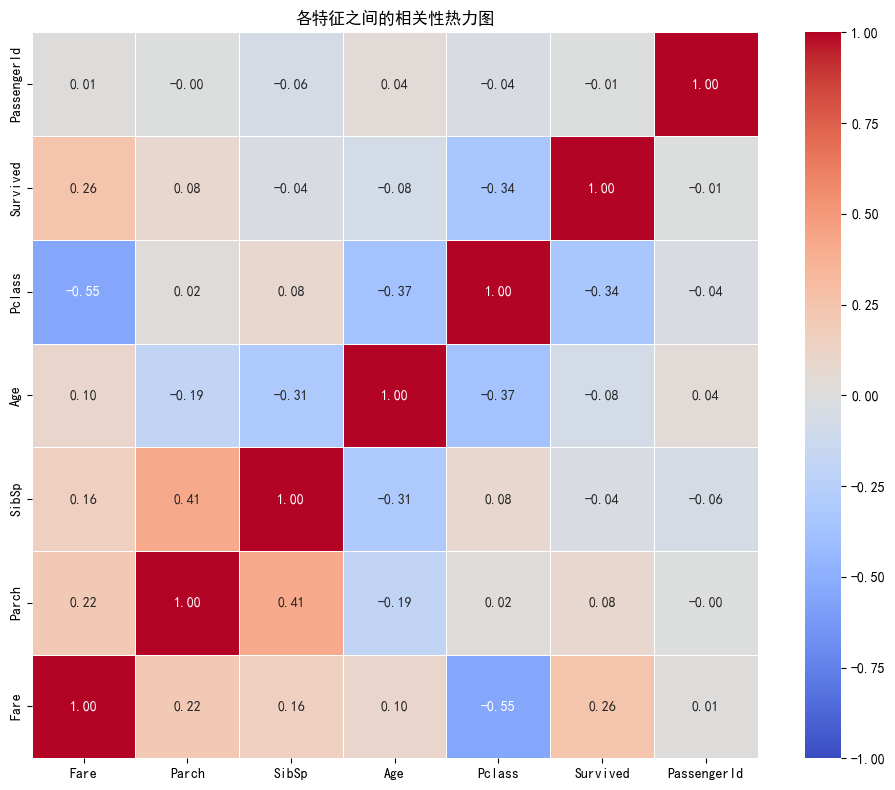

In [55]:
# 选取数值型列计算相关性，绘制热力图，观察各特征之间的线性关系
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()
# 列名倒序排列
corr_matrix = corr_matrix.iloc[:, ::-1]

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', 
            linewidths=0.5, vmin=-1, vmax=1, square=True)
plt.title('各特征之间的相关性热力图')
plt.tight_layout()
plt.show()